# GRU Seq2Seq
history_len = 30  
horizon = 5

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from src.visualization import plot_forecast, plot_forecast_with_train
from src.models.rnn.rnn_seq2seq import RNNSeq2Seq, Encoder, Decoder
from src.models.rnn.train_rnn_seq2seq import train_rnn_seq2seq
from src.evaluation import evaluate, evaluate_by_depth
from src.models.rnn.data_preparing import (
    create_seq2seq_eval_loader,
    create_seq2seq_train_loader
)
from src.models.rnn.predict import predict_seq2seq
from src.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
set_seed(SEED)

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [6]:
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
feature_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']

history_len = 30
horizon = 5

df_train_full = df_train_full[feature_cols + target_cols]
df_train = df_train[feature_cols + target_cols]
df_val = df_val[feature_cols + target_cols]
df_test = df_test[feature_cols + target_cols]

In [7]:
batch_size = 64

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()


train_loader = create_seq2seq_train_loader(
    df=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

full_train_loader = create_seq2seq_train_loader(
    df=df_train_full,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=full_feature_scaler,
    target_scaler=full_target_scaler,
    batch_size=batch_size
)

val_loader = create_seq2seq_eval_loader(
    df_eval=df_val,
    df_start=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

In [17]:
input_size = len(feature_cols) + len(target_cols)
feature_size = len(feature_cols)
target_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    set_seed(SEED + trial.number)
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 4)
    
    if num_layers == 1:
        dropout = 0.0
    else:
        dropout = trial.suggest_float('dropout', 0.0, 0.4)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    encoder_trial = Encoder(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    decoder_trial = Decoder(
        feature_size=feature_size,
        target_size=target_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    model_trial = RNNSeq2Seq(
        encoder=encoder_trial,
        decoder=decoder_trial,
        target_size=len(target_cols)
    ).to(device)
    
    optimizer_trial = optim.AdamW(
        model_trial.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
    model_trial, history = train_rnn_seq2seq(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        teacher_forcing_ratio=0.5,
        scheduler=scheduler,
        device=device,
        epochs=100,
        max_epochs_no_improvement=10,
        verbose=False
    )
    
    trial.set_user_attr('actual_dropout', dropout)
    trial.set_user_attr('best_epoch', history['best_epoch'])
    trial.set_user_attr('total_epochs', len(history['val_rmse']))
    
    best_val_rmse = float(history['best_val_rmse'][-1])
    return best_val_rmse

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=10)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-13 13:55:32,692] A new study created in memory with name: no-name-1cee51ca-d965-462e-8d6d-1455b0c7f552
[I 2026-06-13 13:55:56,926] Trial 0 finished with value: 0.10942699015140533 and parameters: {'hidden_size': 64, 'num_layers': 4, 'dropout': 0.292797576724562, 'lr': 0.00015751320499779721, 'weight_decay': 2.0513382630874486e-05}. Best is trial 0 with value: 0.10942699015140533.
[I 2026-06-13 13:56:12,694] Trial 1 finished with value: 0.09529836475849152 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 0.0005399484409787432, 'weight_decay': 0.00015930522616241006}. Best is trial 1 with value: 0.09529836475849152.
[I 2026-06-13 13:56:27,600] Trial 2 finished with value: 0.07127058506011963 and parameters: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0008706020878304854, 'weight_decay': 0.000462258900102083}. Best is trial 2 with value: 0.07127058506011963.
[I 2026-06-13 13:56:42,881] Trial 3 finished with value: 0.3036612272262573 and parameters: {'hidden_size': 4

Early stopping on 84 epoch


[I 2026-06-13 13:58:21,890] Trial 8 finished with value: 0.7884387969970703 and parameters: {'hidden_size': 16, 'num_layers': 3, 'dropout': 0.17606099749584053, 'lr': 1.7541893487450798e-05, 'weight_decay': 9.7803370166594e-05}. Best is trial 2 with value: 0.07127058506011963.
[I 2026-06-13 13:58:45,339] Trial 9 finished with value: 0.1665332019329071 and parameters: {'hidden_size': 16, 'num_layers': 4, 'dropout': 0.10351199264000677, 'lr': 0.00021137059440645722, 'weight_decay': 4.201672054372529e-05}. Best is trial 2 with value: 0.07127058506011963.


Лучшие параметры:  {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0008706020878304854, 'weight_decay': 0.000462258900102083}
Количество эпох в лучшем запуске:  100


In [18]:
encoder = Encoder(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

decoder = Decoder(
    feature_size=feature_size,
    target_size=target_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

model = RNNSeq2Seq(
    encoder=encoder,
    decoder=decoder,
    target_size=len(target_cols)
).to(device)
optimizer = optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model, _ = train_rnn_seq2seq(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    teacher_forcing_ratio=0.5,
    scheduler=scheduler,
    device=device,
    epochs=study.best_trial.user_attrs['best_epoch'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/99 | Train Loss: 0.6693
Epoch 2/99 | Train Loss: 0.1602
Epoch 3/99 | Train Loss: 0.0829
Epoch 4/99 | Train Loss: 0.0417
Epoch 5/99 | Train Loss: 0.0368
Epoch 6/99 | Train Loss: 0.0315
Epoch 7/99 | Train Loss: 0.0256
Epoch 8/99 | Train Loss: 0.0211
Epoch 9/99 | Train Loss: 0.0183
Epoch 10/99 | Train Loss: 0.0173
Epoch 11/99 | Train Loss: 0.0153
Epoch 12/99 | Train Loss: 0.0131
Epoch 13/99 | Train Loss: 0.0149
Epoch 14/99 | Train Loss: 0.0111
Epoch 15/99 | Train Loss: 0.0118
Epoch 16/99 | Train Loss: 0.0095
Epoch 17/99 | Train Loss: 0.0113
Epoch 18/99 | Train Loss: 0.0091
Epoch 19/99 | Train Loss: 0.0108
Epoch 20/99 | Train Loss: 0.0088
Epoch 21/99 | Train Loss: 0.0093
Epoch 22/99 | Train Loss: 0.0077
Epoch 23/99 | Train Loss: 0.0077
Epoch 24/99 | Train Loss: 0.0065
Epoch 25/99 | Train Loss: 0.0075
Epoch 26/99 | Train Loss: 0.0176
Epoch 27/99 | Train Loss: 0.0136
Epoch 28/99 | Train Loss: 0.0197
Epoch 29/99 | Train Loss: 0.0127
Epoch 30/99 | Train Loss: 0.0066
Epoch 31/99 | Train

In [ ]:
# model_path = 'models/gru_seq2seq_v7.pth'
# weights_path = 'models/gru_seq2seq_v7_weights.pth'

# torch.save(model, model_path)
# torch.save(model.state_dict(), weights_path)

# model = torch.load(model_path, weights_only=False)

In [10]:
model = torch.load('models/gru_seq2seq_v3_best.pth', weights_only=False)

                              RMSE       MAE       ME       NSE
Значение для всех глубин  0.620851  0.483618 -0.12076  0.966584
      48-1 (0)
RMSE  2.650116
MAE   2.132726
ME   -0.219576
NSE   0.919003


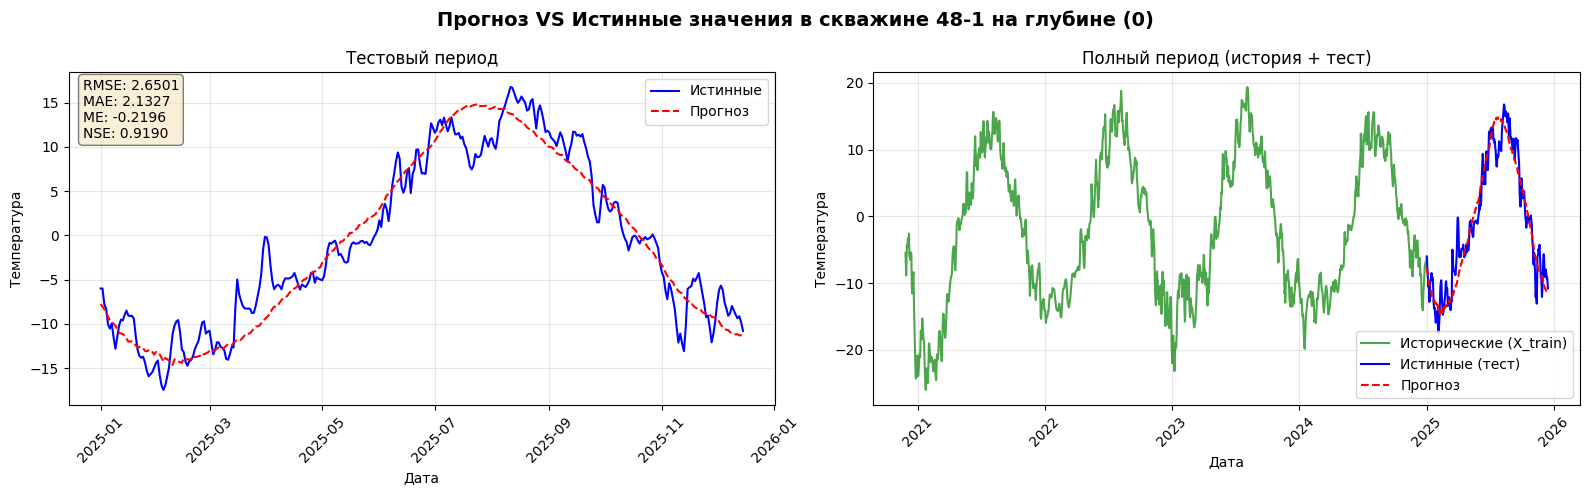

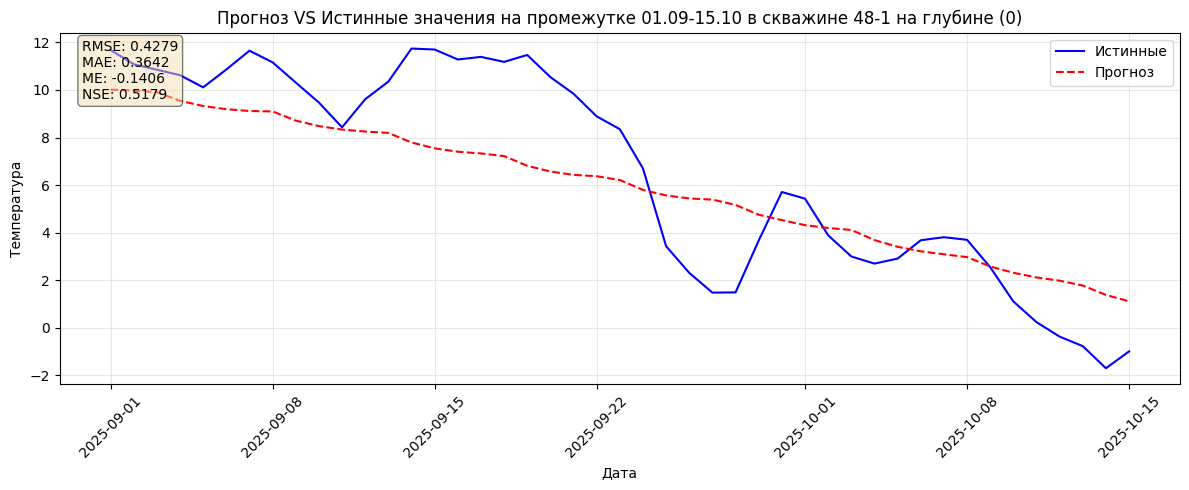

     48-1 (0,5)
RMSE   1.715705
MAE    1.313479
ME    -0.294975
NSE    0.940058


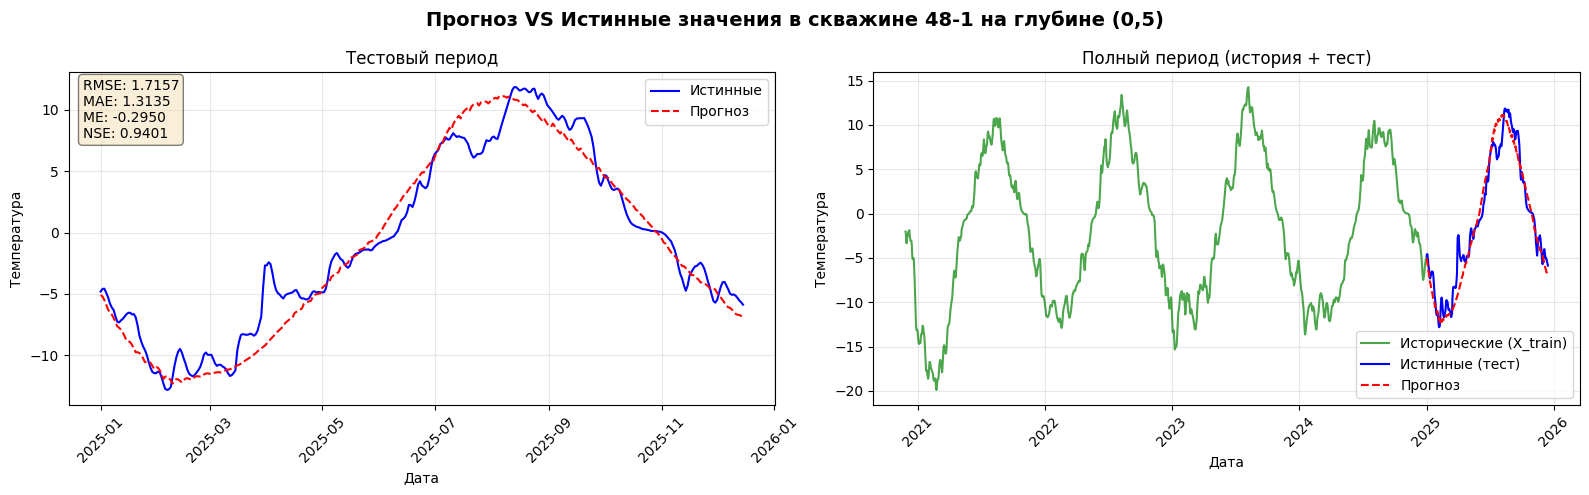

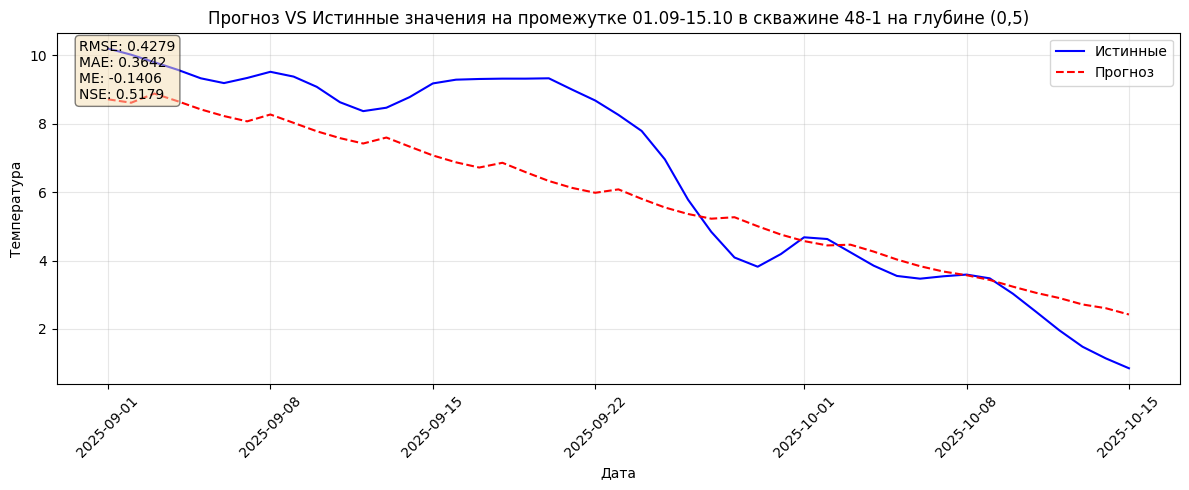

      48-1 (1)
RMSE  1.136664
MAE   0.884741
ME   -0.266703
NSE   0.955915


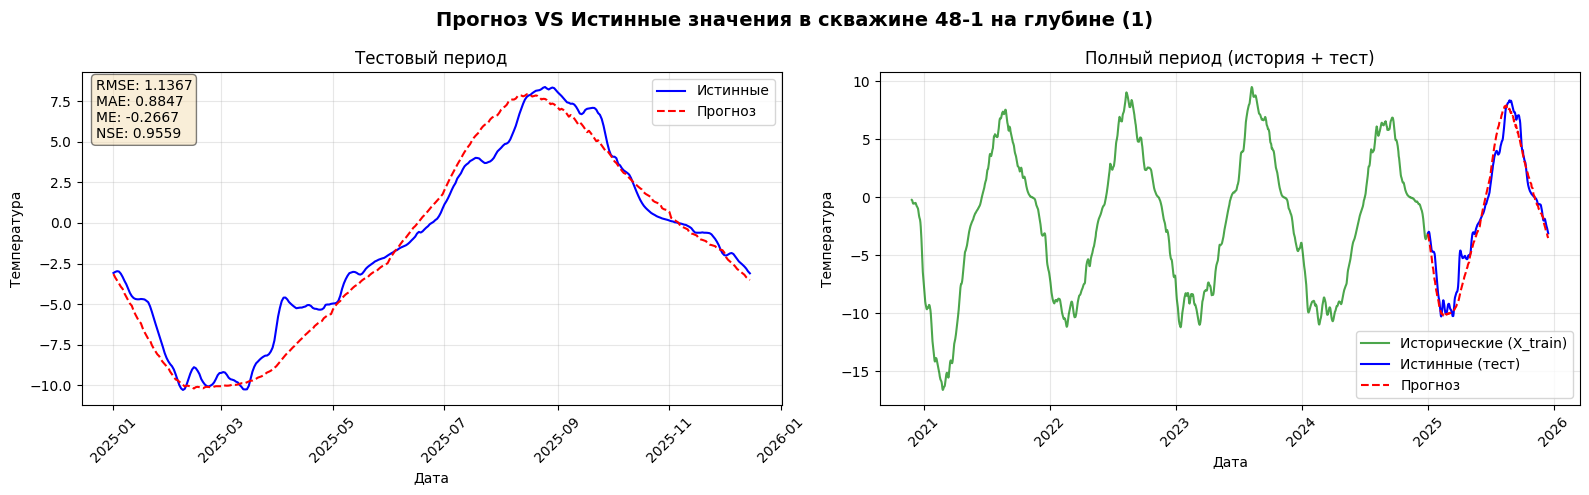

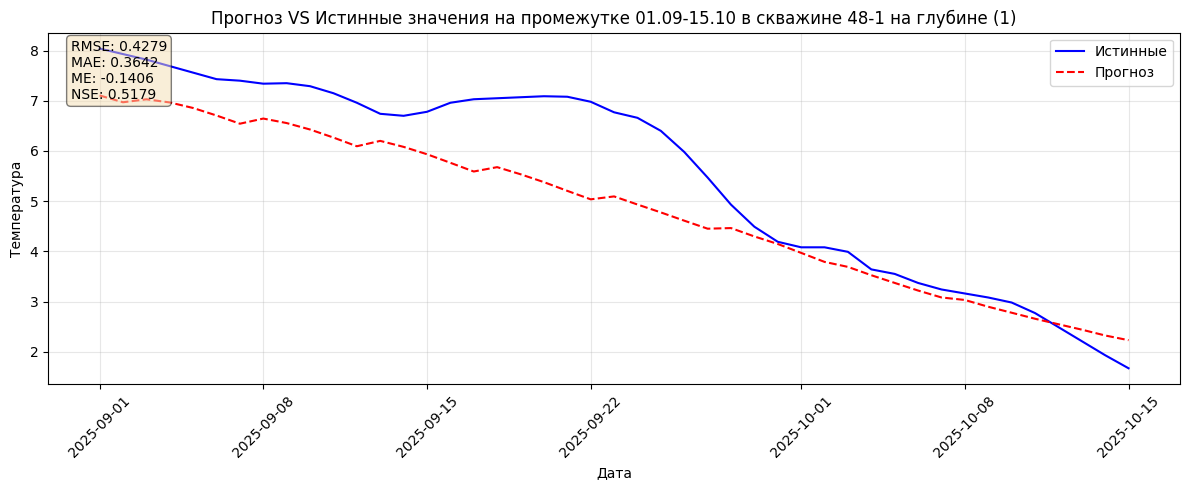

     48-1 (1,5)
RMSE    0.81802
MAE     0.62863
ME     -0.20527
NSE     0.96514


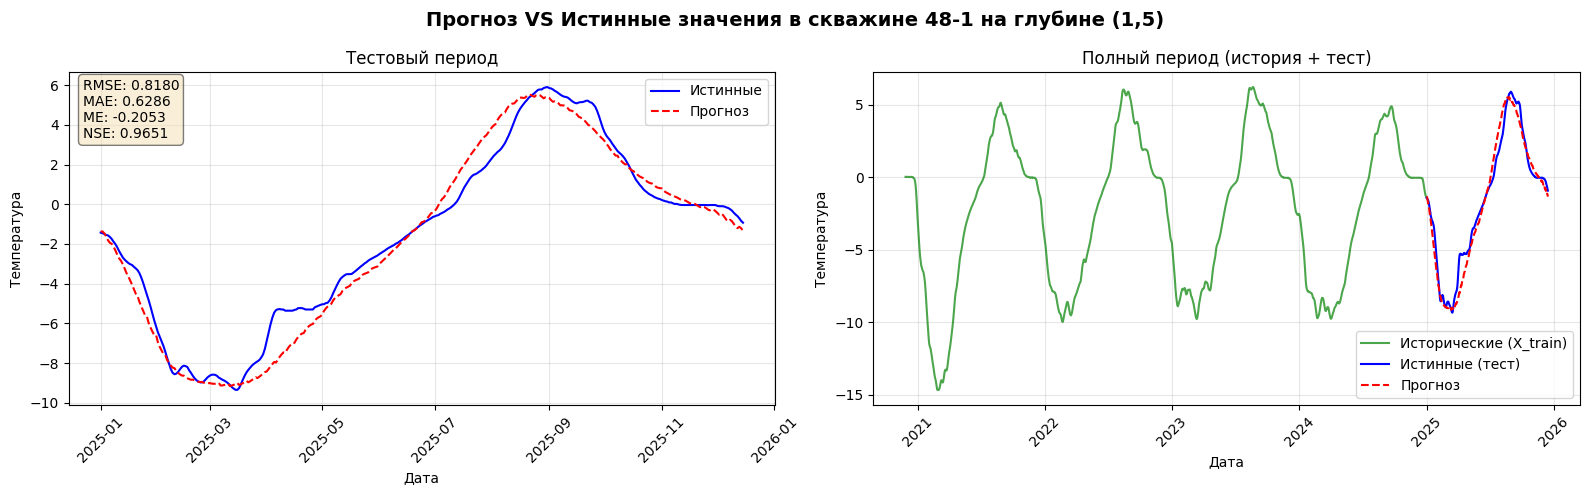

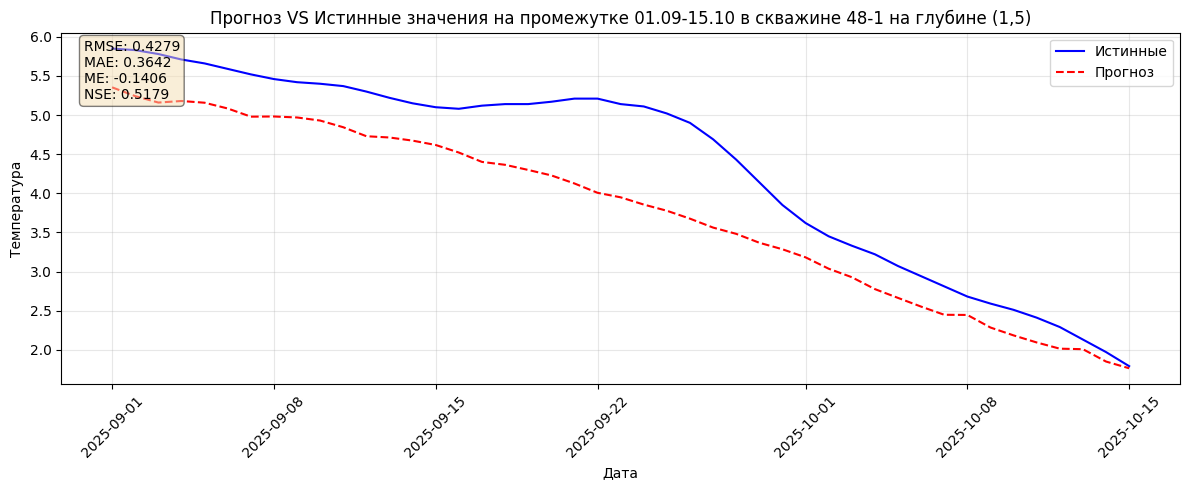

      48-1 (2)
RMSE  0.559455
MAE   0.416729
ME   -0.138873
NSE   0.974551


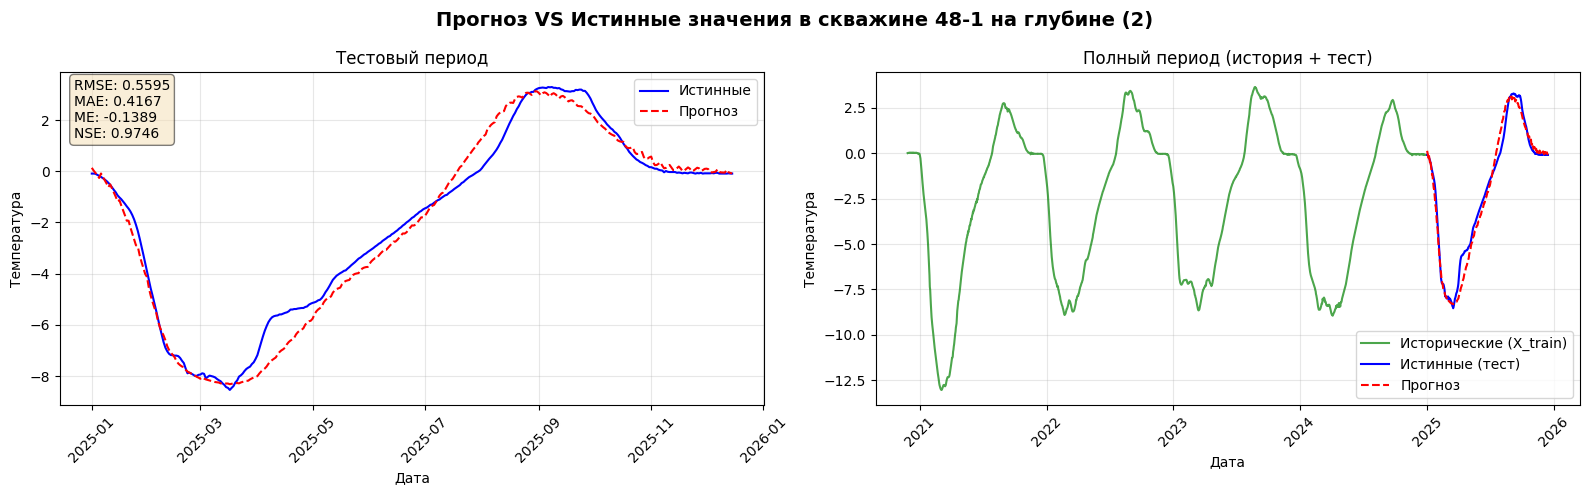

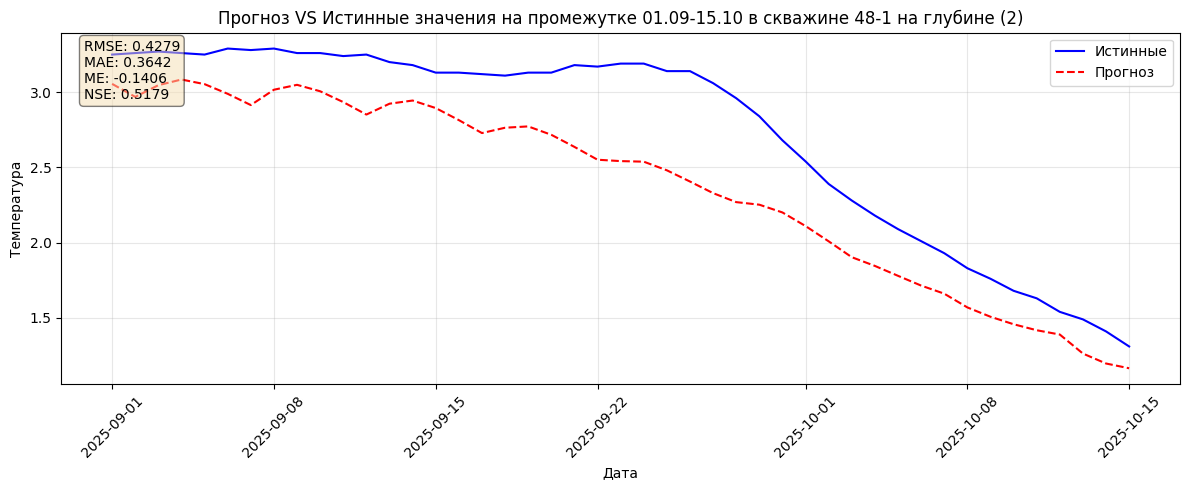

     48-1 (2,5)
RMSE   0.367332
MAE     0.25458
ME    -0.116675
NSE    0.982418


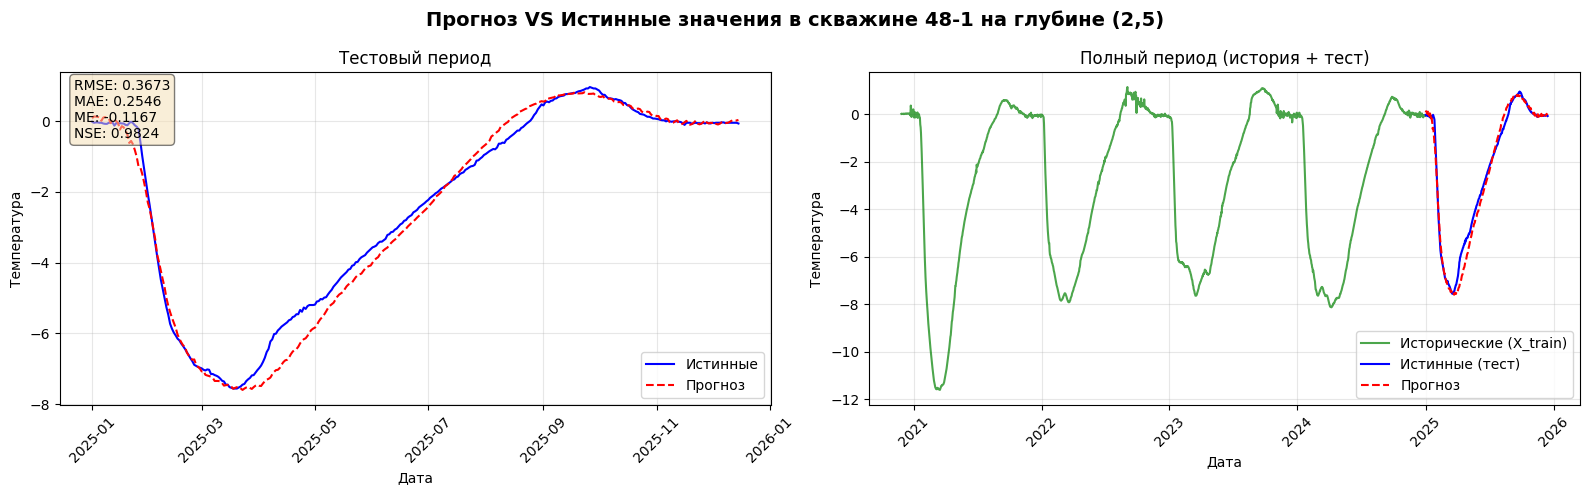

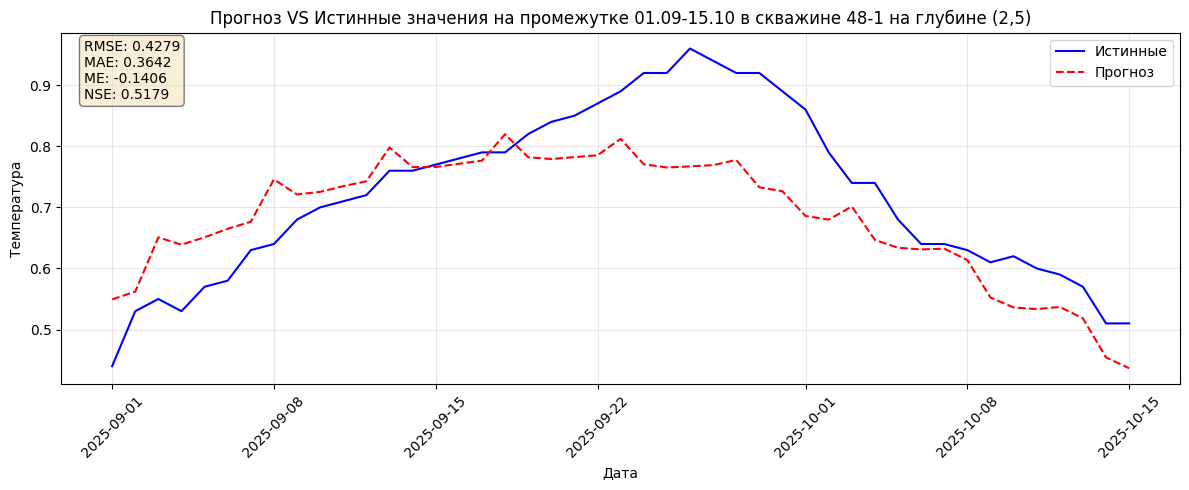

      48-1 (3)
RMSE  0.316613
MAE   0.221798
ME   -0.109074
NSE    0.98317


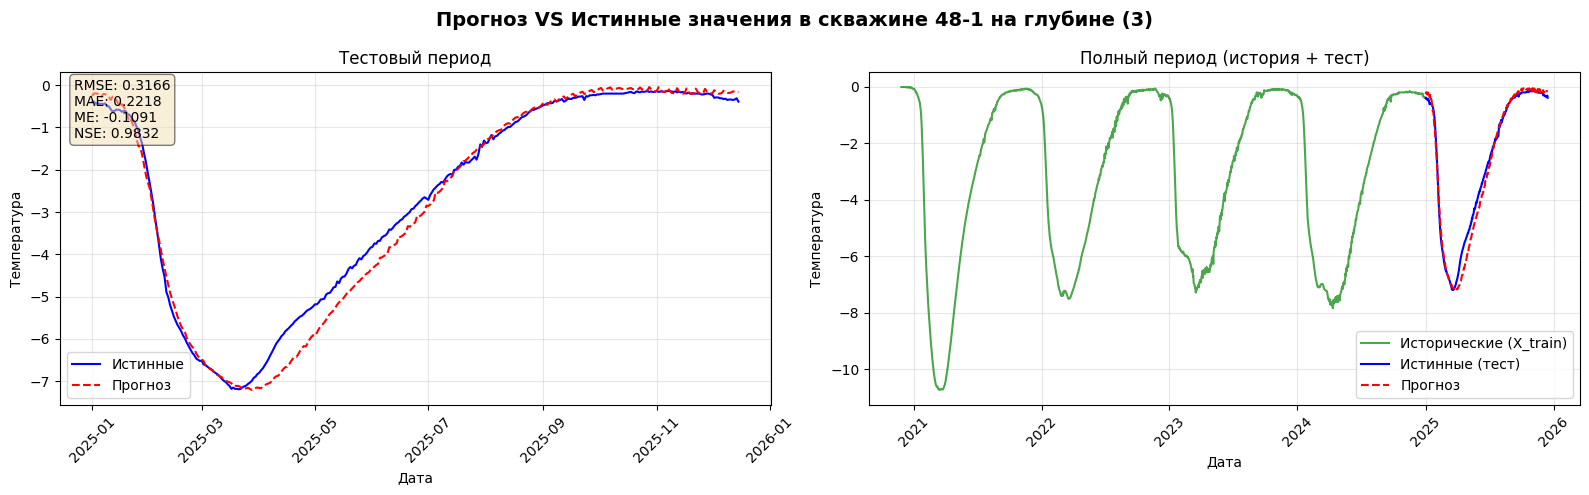

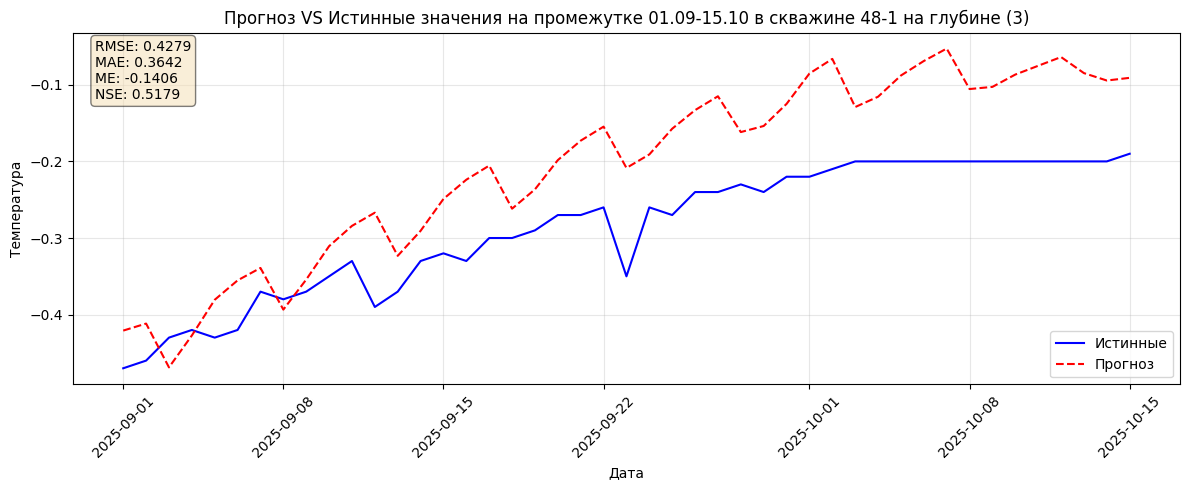

     48-1 (3,5)
RMSE   0.302292
MAE    0.211245
ME    -0.122513
NSE    0.981708


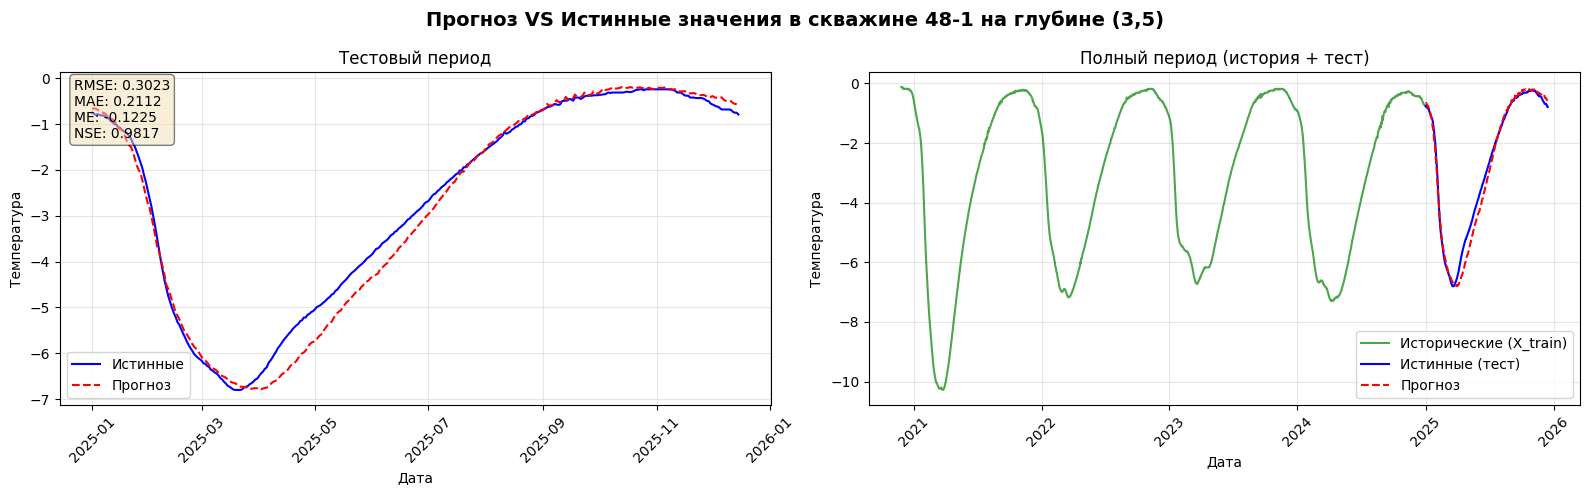

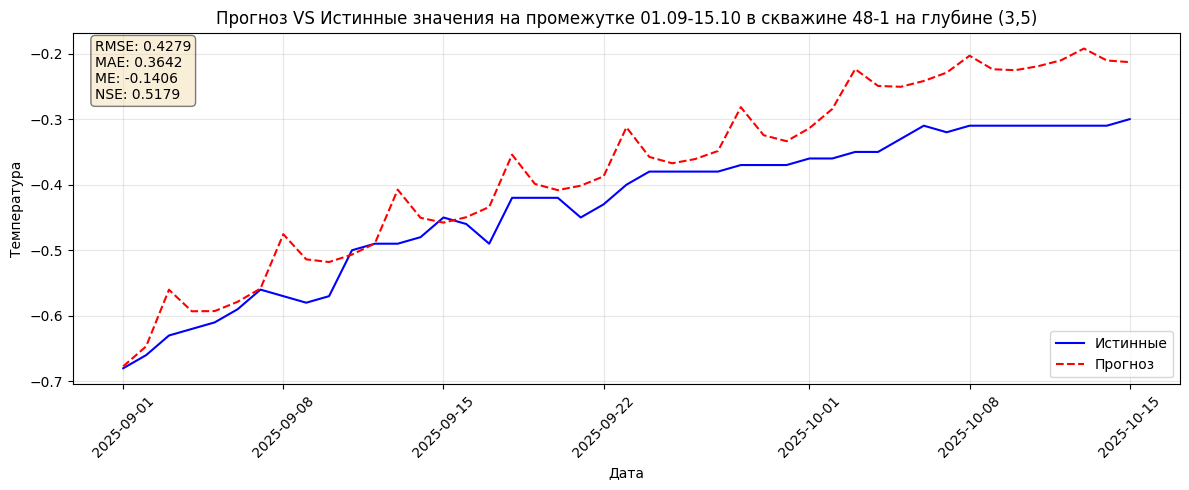

      48-1 (4)
RMSE  0.300727
MAE   0.232556
ME   -0.104056
NSE    0.97795


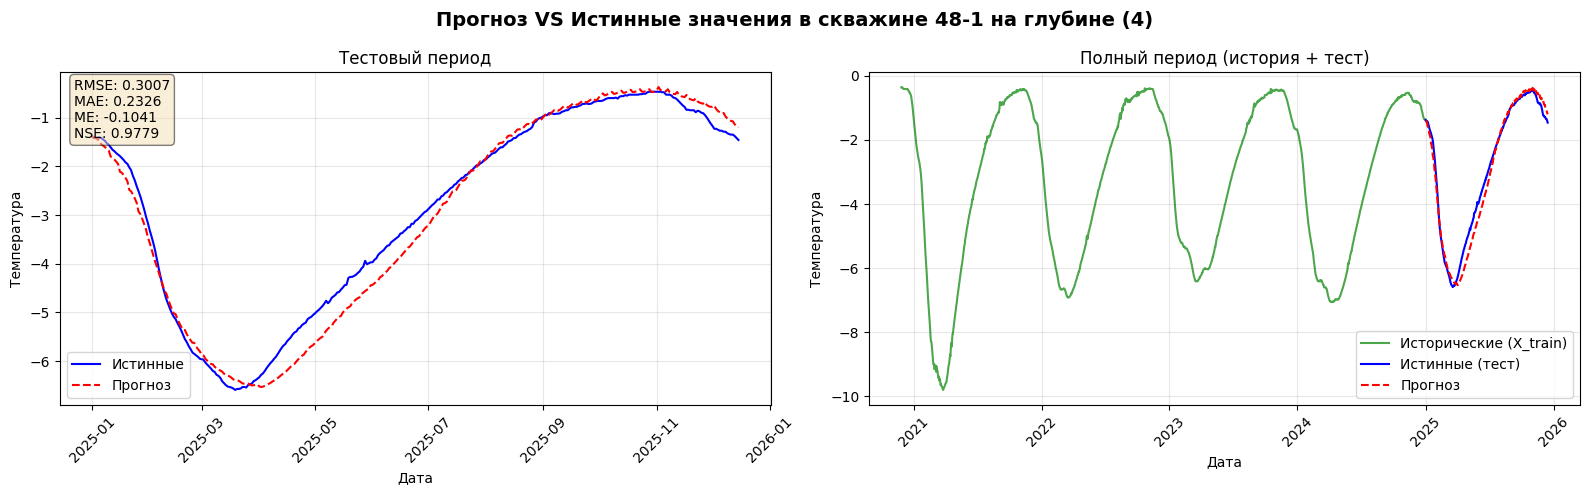

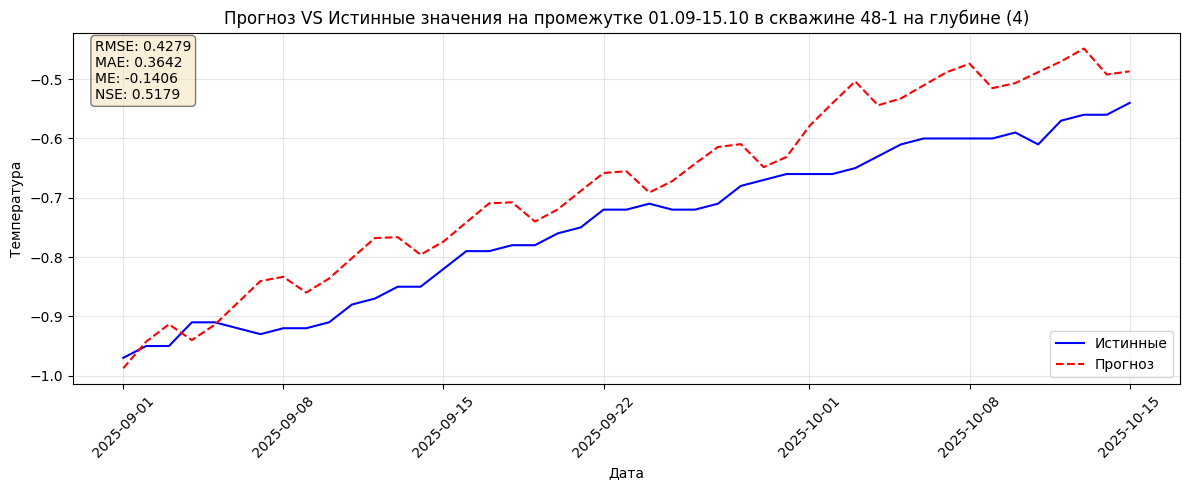

     48-1 (4,5)
RMSE   0.301592
MAE    0.233976
ME    -0.117577
NSE    0.975519


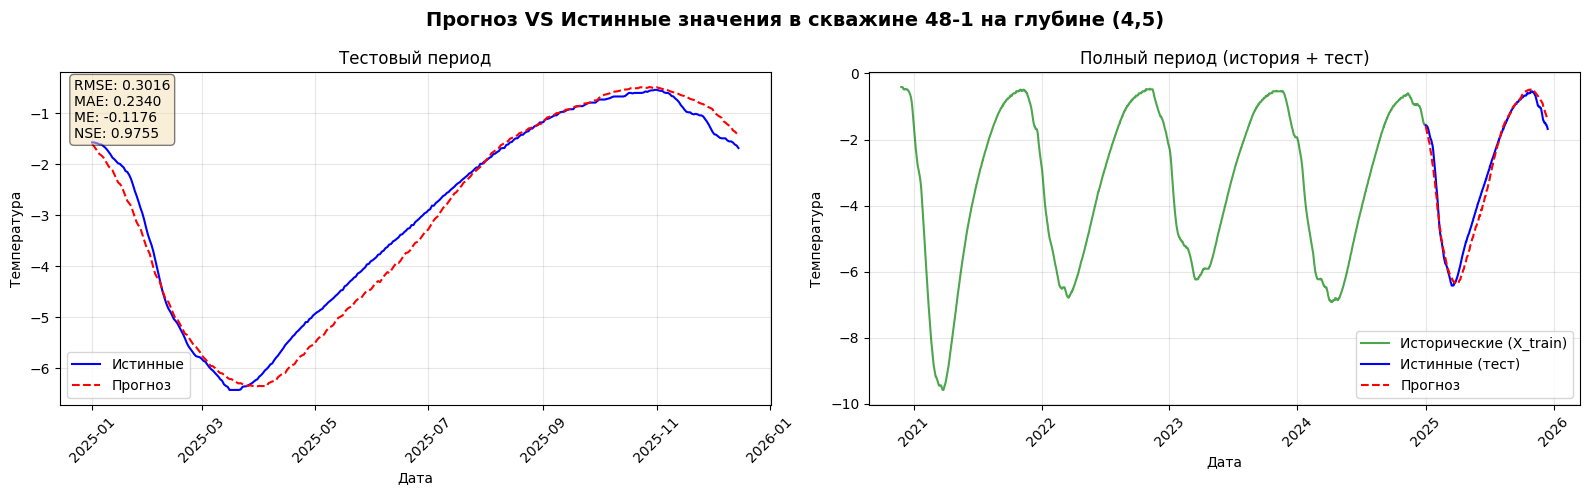

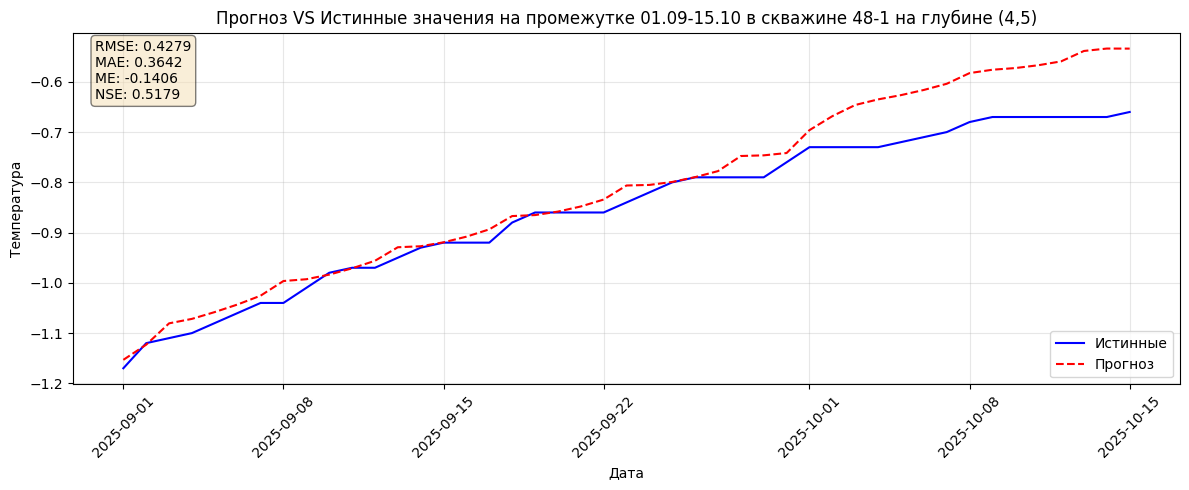

      48-1 (5)
RMSE  0.294506
MAE   0.225762
ME   -0.129771
NSE   0.974214


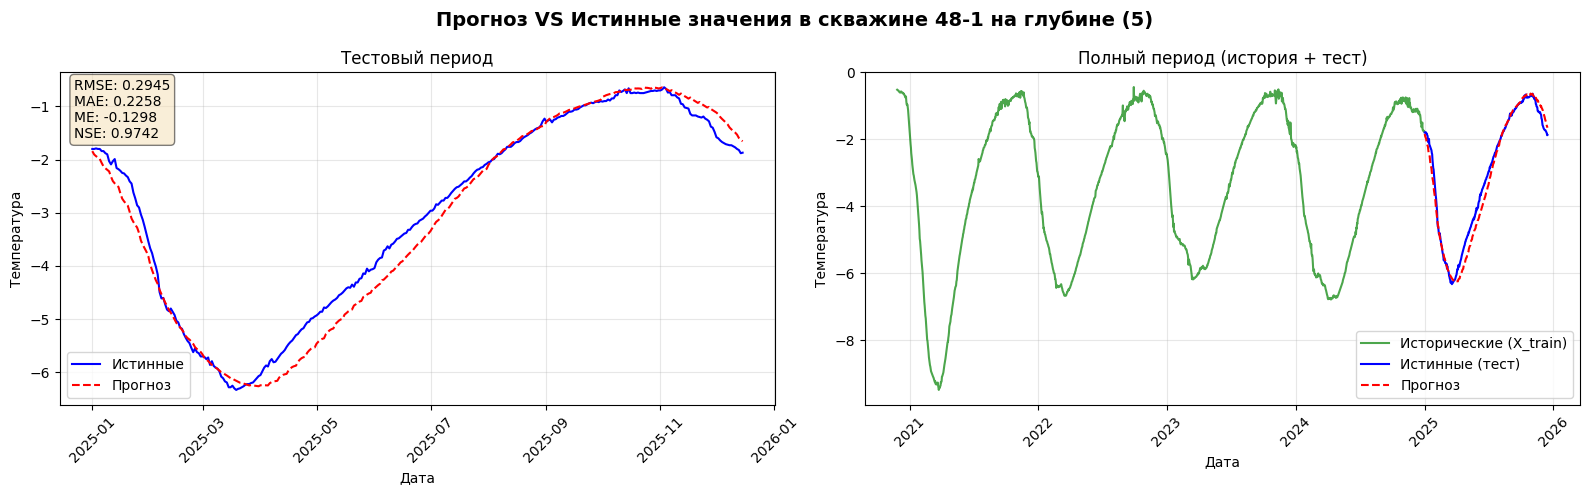

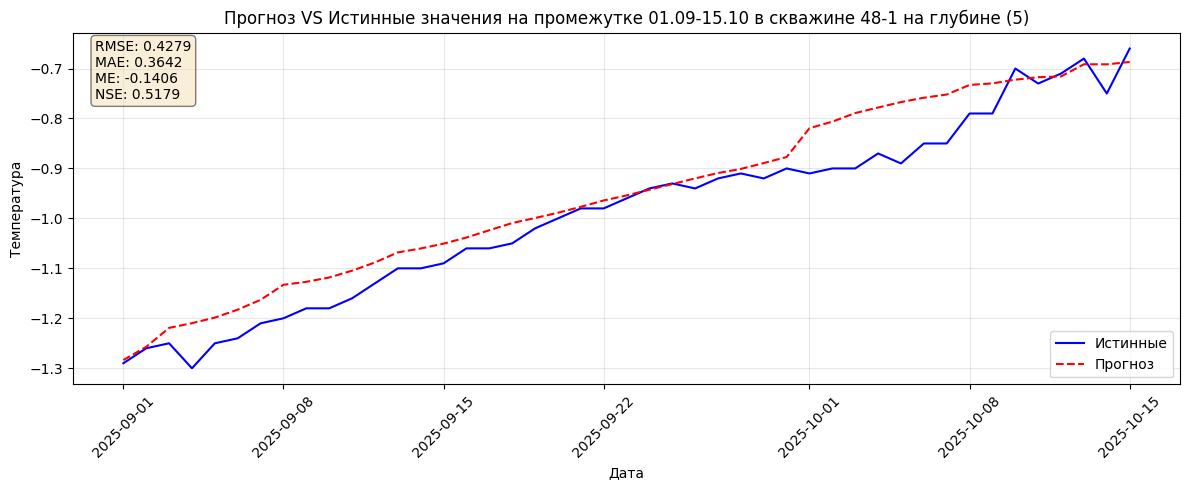

      48-1 (6)
RMSE  0.301283
MAE   0.241095
ME   -0.092578
NSE   0.967707


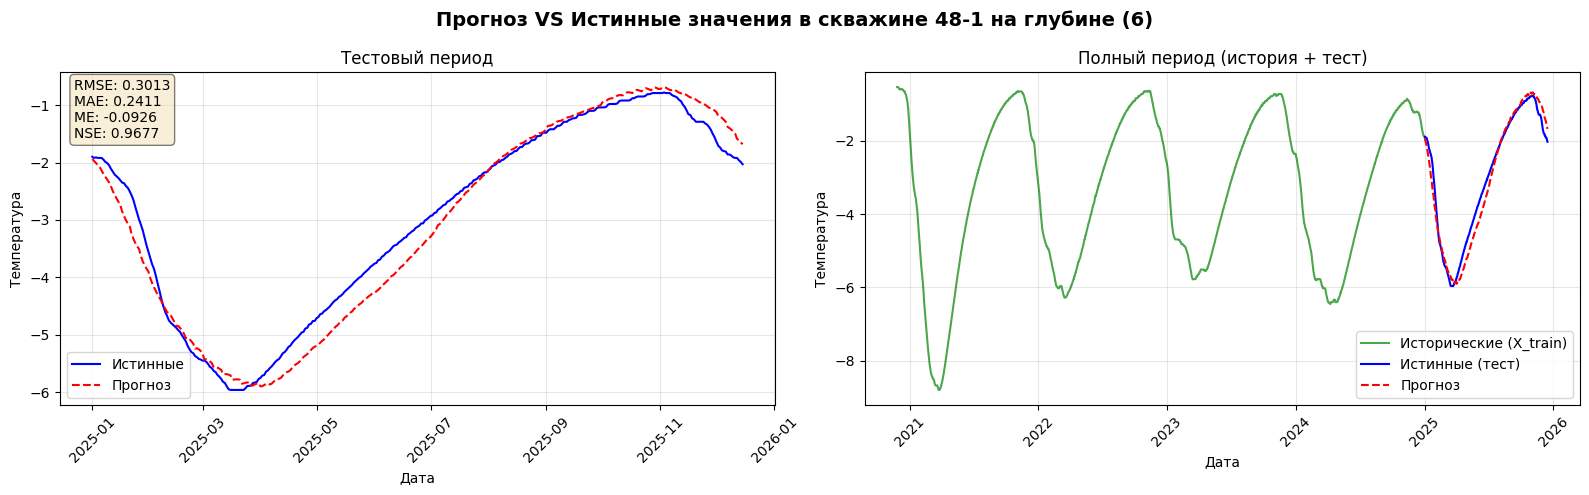

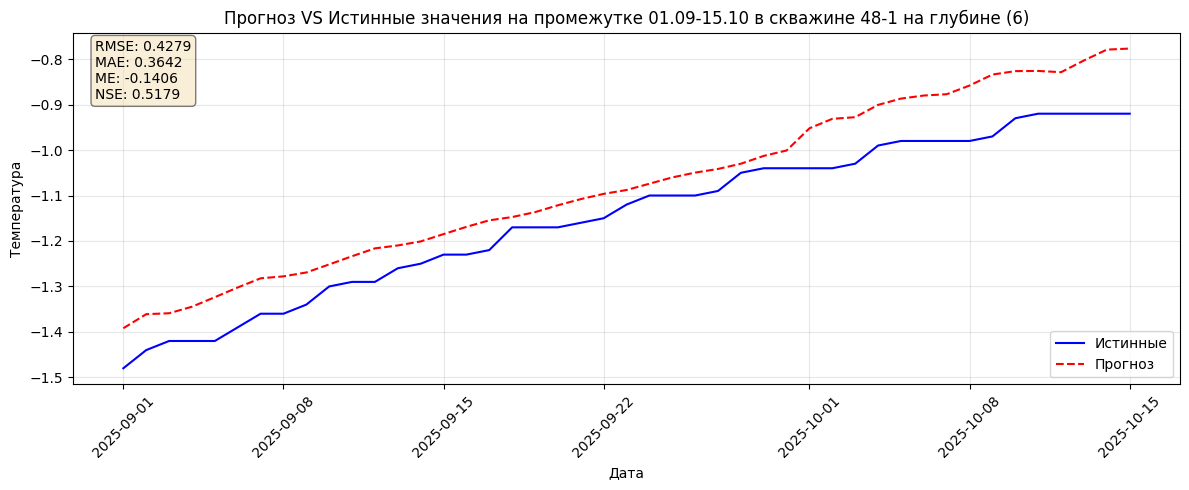

      48-1 (7)
RMSE  0.283467
MAE   0.233775
ME   -0.059565
NSE   0.965111


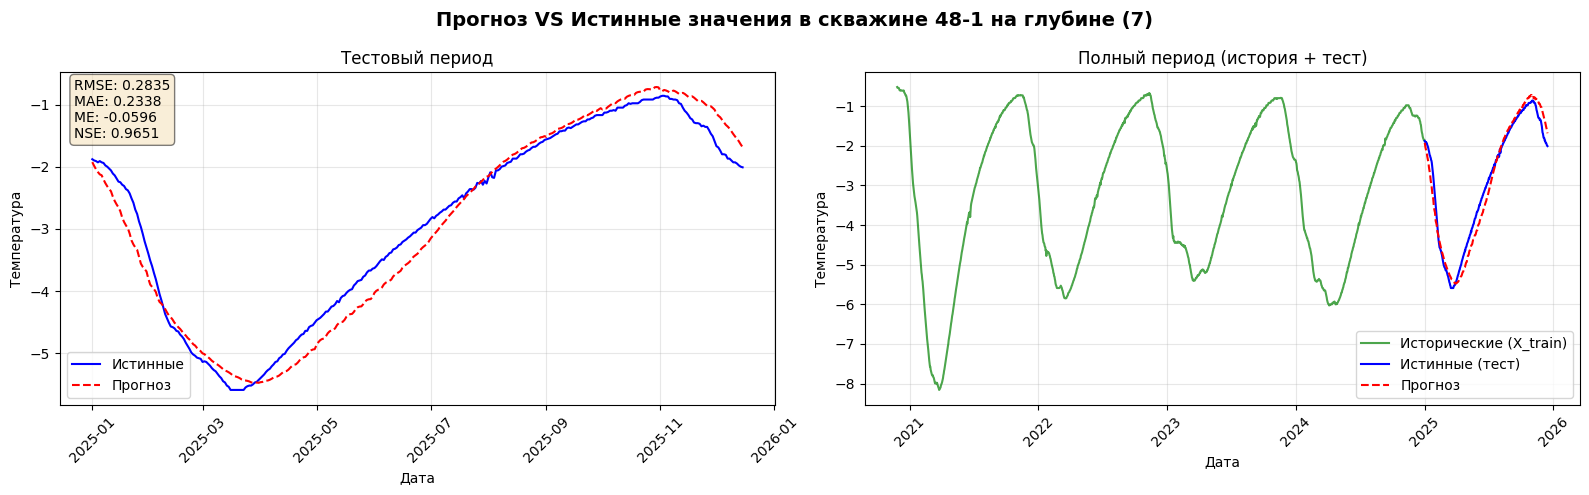

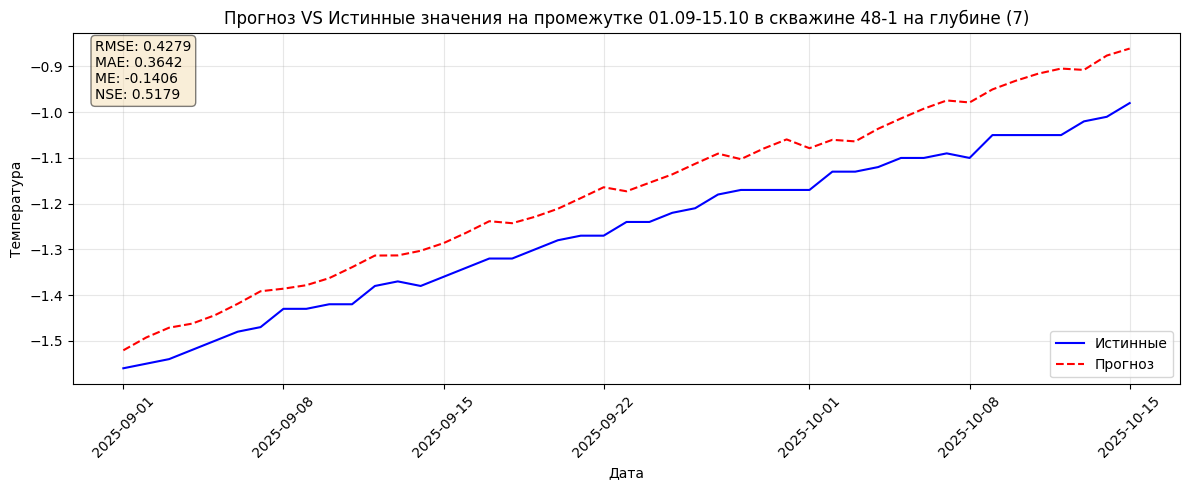

      48-1 (8)
RMSE  0.248353
MAE    0.20876
ME   -0.039805
NSE   0.964654


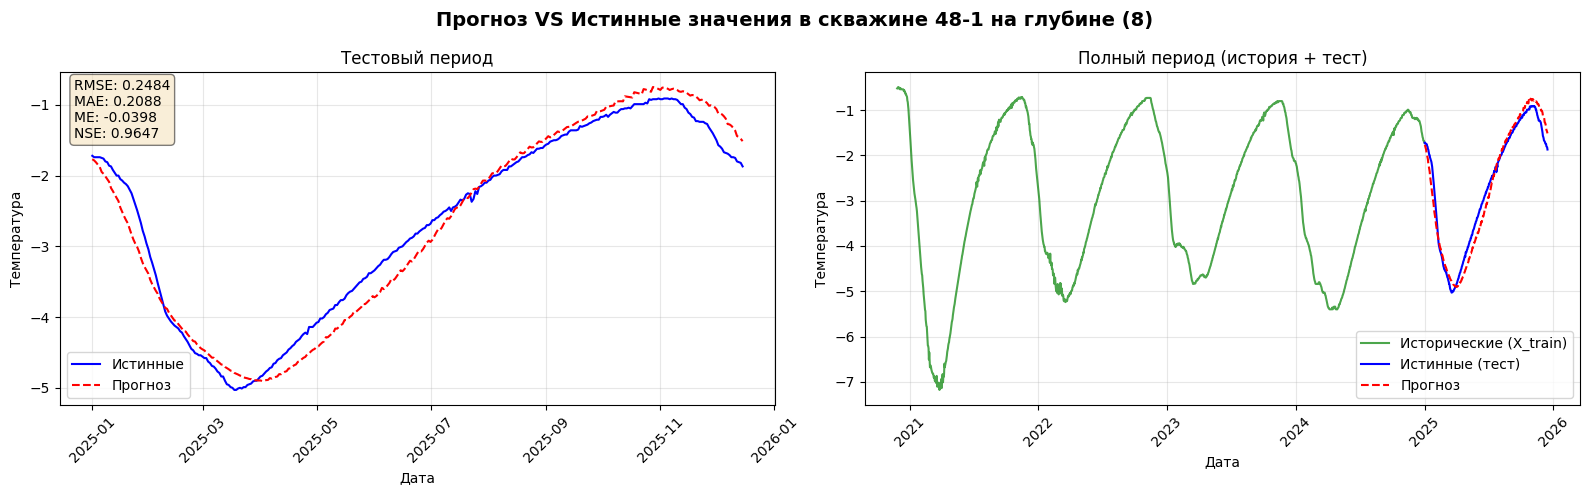

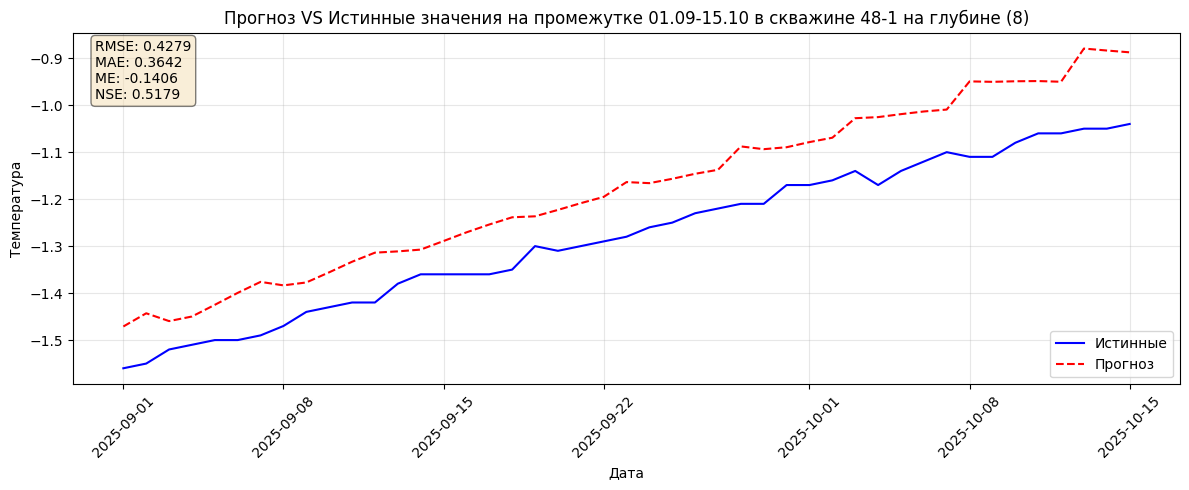

      48-1 (9)
RMSE  0.188607
MAE   0.167401
ME    0.016193
NSE   0.969363


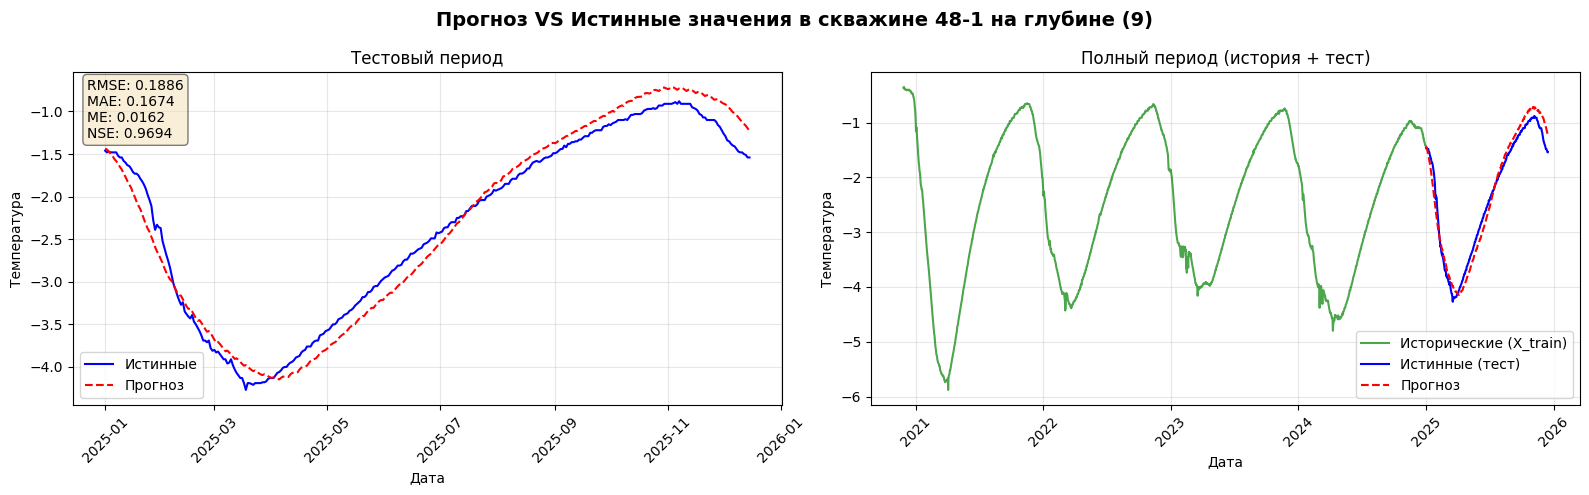

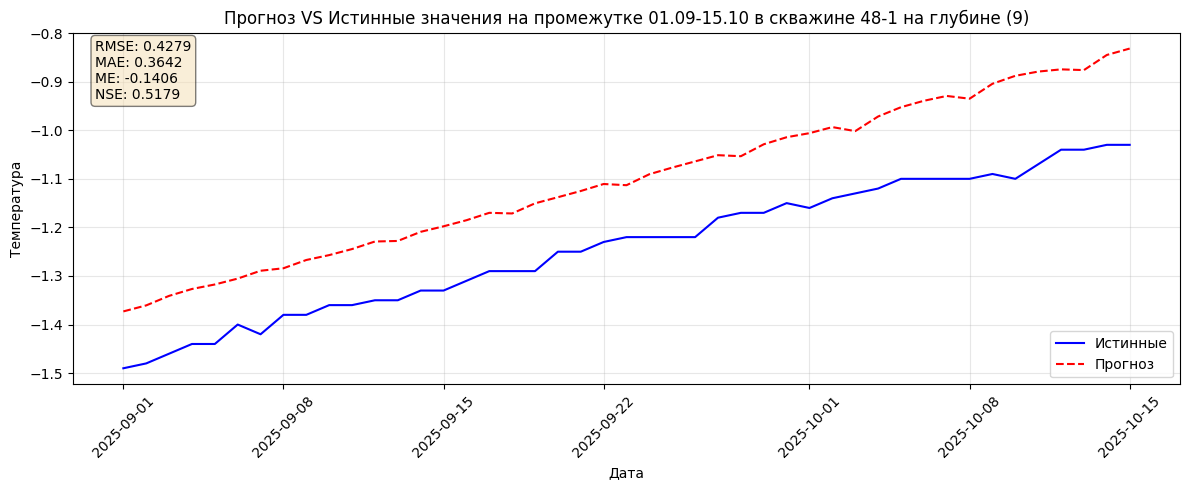

     48-1 (10)
RMSE   0.14888
MAE   0.130633
ME    0.068654
NSE   0.968873


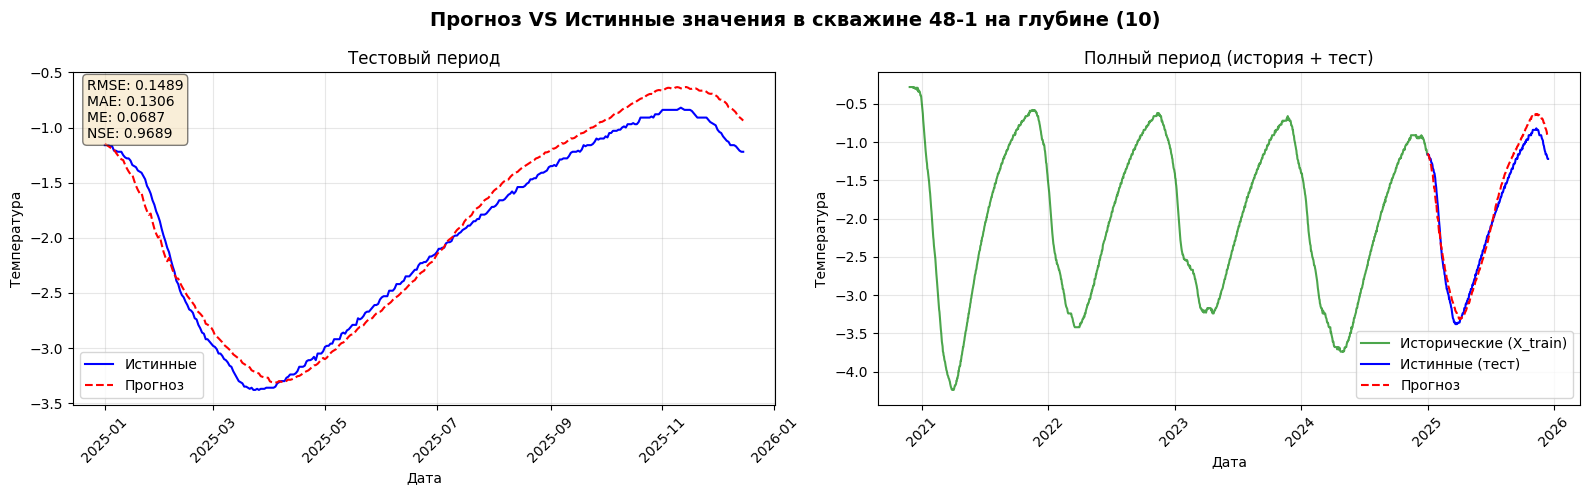

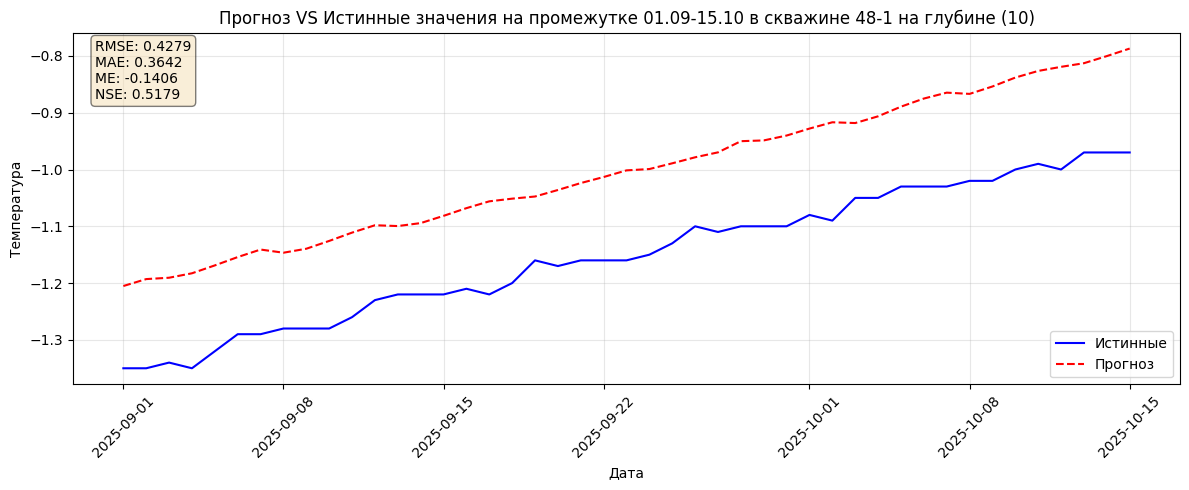

In [11]:
y_pred = predict_seq2seq(
    model=model,
    df_history=df_val,
    df_test=df_test,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    feature_cols=feature_cols,
    target_cols=target_cols,
    history_len=history_len,
    horizon=horizon,
    device=device,
)
y_true = df_test[target_cols]

eval_dict = evaluate(y_true, y_pred)
print(pd.DataFrame(eval_dict, index=['Значение для всех глубин']))

eval_by_depth_df = evaluate_by_depth(y_true.values, y_pred.values, target_cols)
y_true_autumn = y_true['2025-09-01':'2025-10-15']
y_pred_autumn = y_pred['2025-09-01':'2025-10-15']
metrics_autumn = evaluate(y_true_autumn.values, y_pred_autumn.values)
for i, col in enumerate(target_cols):
    metrics = eval_by_depth_df.loc[col]
    print(metrics.to_frame()[1:])
    
    plot_forecast_with_train(
        df_train_full[col],
        pd.DataFrame(y_true[col]),
        pd.DataFrame(y_pred[col]),
        metrics_dict=metrics[1:].to_dict(),
        title=f'Прогноз VS Истинные значения в скважине {col.split()[0]} на глубине {col.split()[1]}'
    )
    plot_forecast(
        pd.DataFrame(y_true_autumn[col]),
        pd.DataFrame(y_pred_autumn[col]),
        metrics_dict=metrics_autumn,
        title=f'Прогноз VS Истинные значения на промежутке 01.09-15.10 в скважине {col.split()[0]} на глубине {col.split()[1]}'
    )